In [148]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [149]:
condition = "4mod_all_step2"
checkpoint_epoch = 0
n_samples_test = 1000
split = "test"


In [150]:
experiment_name = get_experiment_name(condition, "biased_00", 0)
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color'})]['color']
original_v_latents = test_samples[frozenset({'v_latents'})]['v_latents']
cat = test_samples[frozenset({'cat'})]['cat']

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)




/home/lucas/.cache/pypoetry/virtualenvs/alexis-n7zQ69N0-py3.11/lib/python3.11/site-packages/lightning/fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
/home/luc

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/4mod_all_step2_biased_00/checkpoints/last.ckpt
Weights loaded, optimizer and scheduler remain fresh!
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/4mod_all_step2_biased_00/checkpoints/last.ckpt


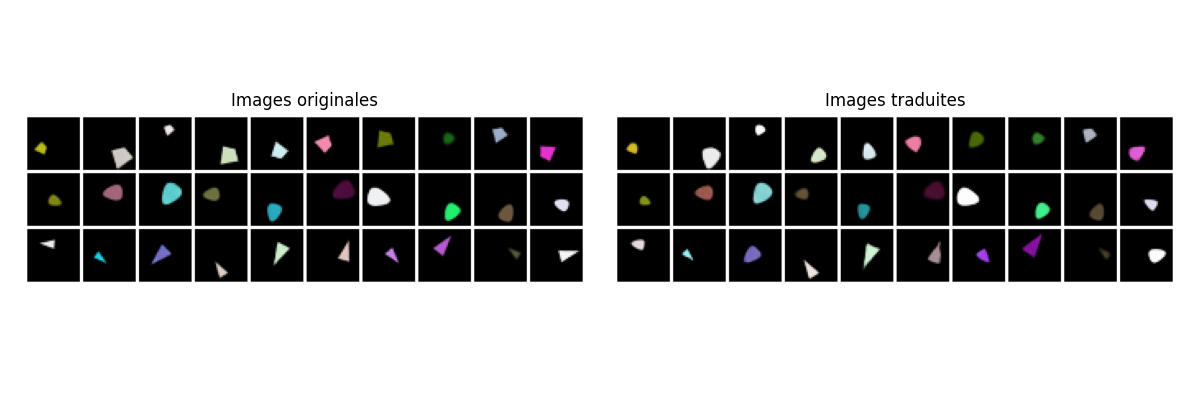

In [151]:
# demi cycle v_latents
domain_name_source = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
dcy = gw_mod.decode(z, domains={domain_name_source})

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_dcy= visual_module.decode_images(dcy['v_latents'])
original_images_rgb = visual_module.decode_images(original_v_latents)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_dcy, cat, 10))
plt.show()


In [152]:
# translation_v_latents_to_color

domain_name_source = 'v_latents'
domain_name_target = 'color'
latents_source = latent_domains[frozenset({domain_name_source})]

z_v_to_color = gw_mod.encode(latents_source)[domain_name_source]
x_pred_v_to_color = gw_mod.decode(z_v_to_color, domains={domain_name_target})

print('truth')
print(original_colors[0:3])
print('pred')
print(x_pred_v_to_color['color'][0:3])

truth
tensor([[0.9961, 0.9294, 0.9255],
        [0.0745, 0.8706, 0.9608],
        [0.4510, 0.4627, 0.8039]], device='cuda:0')
pred
tensor([[0.7184, 0.7095, 0.6725],
        [0.1292, 0.9306, 0.9943],
        [0.6605, 0.7262, 0.9481]], device='cuda:0', grad_fn=<SliceBackward0>)


In [153]:
# cat to color to v_latents

# cat_to_color
domain_name_source = 'cat'
domain_name_target = 'color'
latents_source = latent_domains[frozenset({domain_name_source})]

z_cat_to_color = gw_mod.encode(latents_source)[domain_name_source]
x_pred_cat_to_color = gw_mod.decode(z_cat_to_color, domains={domain_name_target})

# translation_color_to_v_latents

domain_name_source = 'color'
domain_name_target = 'v_latents'

z_cat_to_col_to_v = gw_mod.encode(x_pred_cat_to_color)[domain_name_source]
x_pred_cat_to_col_to_v = gw_mod.decode(z_cat_to_col_to_v, domains={domain_name_target})


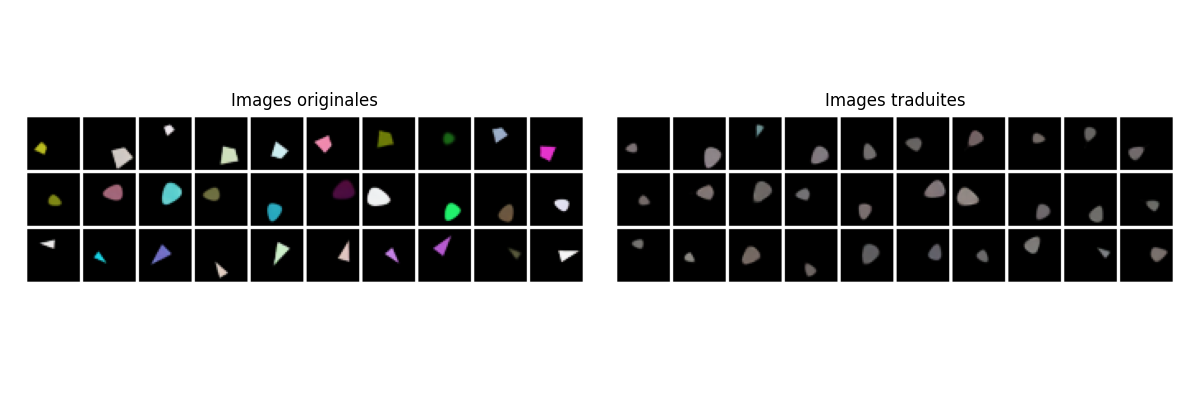

In [154]:
# fustion:cat + position to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]
p = 0.5

gw_latents = gw_mod.encode(latents_source)
z = 1*gw_latents['position'] + 1*gw_latents['cat']

x_pred_cat_pos_to_v = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f = visual_module.decode_images(x_pred_cat_pos_to_v)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()


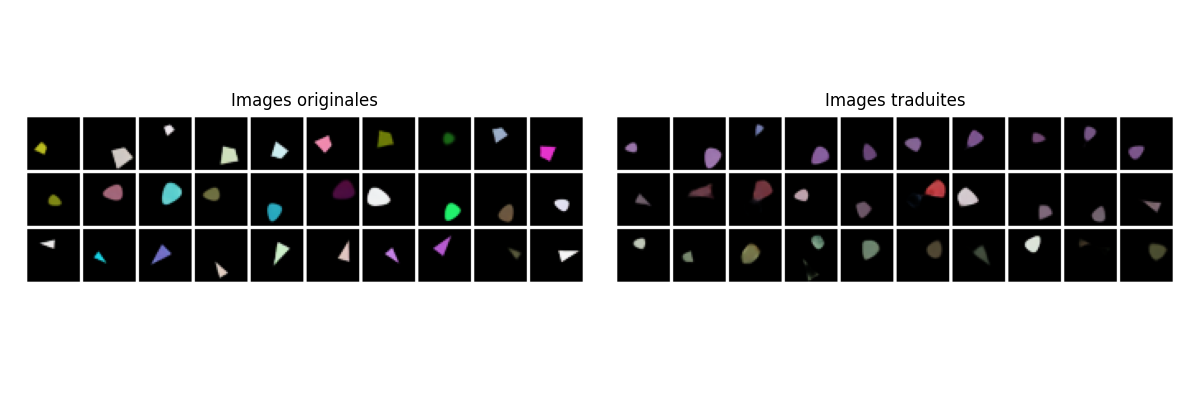

In [155]:
p = 0.5
t = 1*x_pred_cat_pos_to_v+ 1*x_pred_cat_to_col_to_v['v_latents']
decoded_images_t= visual_module.decode_images(t)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_t, cat, 10))
plt.show()


In [156]:
# est ce qu'on peut reconnaitre la catégorie avec seulement la couleur de l'espace latent attribut?
scaler = StandardScaler()
model = LogisticRegression(max_iter=1000)

colors_np = get_samples_rgb({"train_images": None, "images_decoded": decoded_images_t}, 'decoded_edge')

X = colors_np 
y = cat.argmax(dim=1).detach().cpu().numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")
print("\nDétails par catégorie :")
print(classification_report(y_test, y_pred))

Précision globale (Accuracy) : 97.50%

Détails par catégorie :
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        61
           1       0.96      0.97      0.96        69
           2       1.00      0.97      0.99        70

    accuracy                           0.97       200
   macro avg       0.97      0.98      0.98       200
weighted avg       0.98      0.97      0.98       200



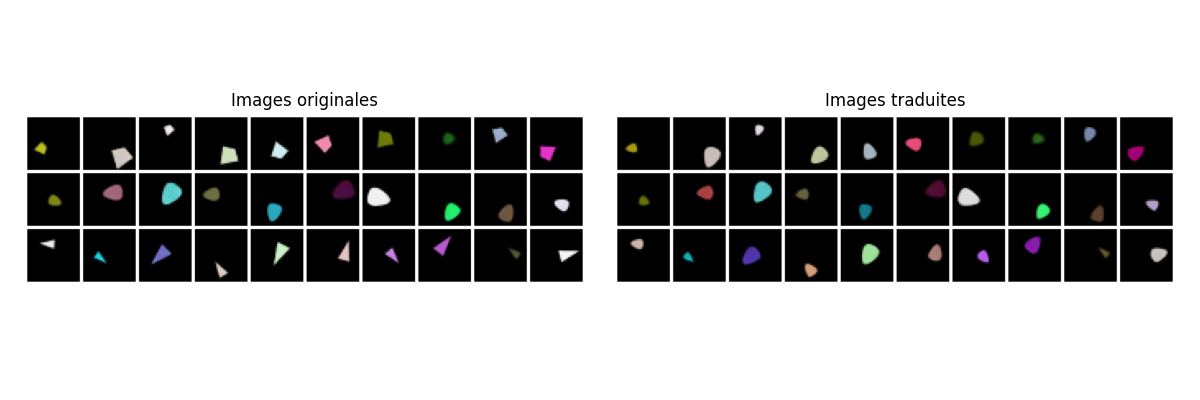

In [159]:
# fustion:cat + position + color to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]


gw_latents = gw_mod.encode(latents_source)
z = 1*gw_latents['color'] + 1*gw_latents['cat'] + 1*gw_latents['position']

prediction = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f= visual_module.decode_images(prediction)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()


In [158]:
# del original_images_rgb
# del decoded_images_dcy
# del decoded_images_f
# del decoded_images_t
# del decoded_images_dt
# torch.cuda.empty_cache()